# FinSight — 03 · Modélisation & Validation

**Objectif :** Entraîner, évaluer et optimiser les modèles de prédiction, en respectant les règles anti-leakage du projet.

**Plan :**
1. Configuration et chargement des données
2. Rappel : pourquoi walk-forward CV ?
3. Analyse des matrices de features
4. Baseline DummyClassifier
5. Modèle XGBoost — tendance (résultats du pipeline)
6. Visualisation : matrice de confusion + courbes ROC
7. Importance des features
8. Optimisation des hyperparamètres
9. Modèle de volatilité
10. Résumé et comparaison finale

## 1. Configuration et chargement

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from src.config import (
    ALL_TICKERS, TICKER_LABELS,
    DATA_PROCESSED_DIR,
    TREND_LABELS, VOLATILITY_LABELS,
    XGBOOST_DEFAULT_PARAMS,
)
from src.data.features import get_feature_names
from src.models.train import walk_forward_splits, train_trend_model, train_volatility_model
from src.models.evaluate import (
    compute_metrics, print_classification_report,
    plot_confusion_matrix, plot_roc_curves,
    plot_feature_importance, summarize_walk_forward,
)
from src.models.predict import load_model, save_model

load_dotenv('../.env')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

FEATURES_DIR = DATA_PROCESSED_DIR / 'features'
print('Imports OK')

Imports OK


In [2]:
# Chargement des matrices de features (générées par scripts/train_pipeline.py)
feature_matrices = {}

for ticker in ALL_TICKERS:
    path = FEATURES_DIR / f"{ticker.replace('=', '_')}_features.csv"
    df = pd.read_csv(path, index_col='Date', parse_dates=True)
    feature_matrices[ticker] = df
    print(f"{ticker:8s} | {df.shape[0]} lignes × {df.shape[1]} colonnes")

# On travaille sur AAPL pour les exemples — actif bien documenté et liquide
TICKER_DEMO = 'AAPL'
df_demo = feature_matrices[TICKER_DEMO]
print(f'\nDataset demo : {TICKER_LABELS[TICKER_DEMO]} ({TICKER_DEMO})')

MC.PA    | 2470 lignes × 25 colonnes
TTE.PA   | 2470 lignes × 25 colonnes
AAPL     | 2425 lignes × 25 colonnes
MSFT     | 2425 lignes × 25 colonnes
GC=F     | 2422 lignes × 25 colonnes
SI=F     | 2422 lignes × 25 colonnes
PL=F     | 2413 lignes × 25 colonnes

Dataset demo : Apple (AAPL)


## 2. Rappel : pourquoi walk-forward CV ?

Sur des séries temporelles financières, la règle absolue est :

> **Le modèle ne peut jamais s'entraîner sur des données postérieures à celles qu'il prédit.**

Le walk-forward CV simule exactement ce qui se passe en production :
- Split 1 : entraîne sur 2015–2016, teste sur 2017
- Split 2 : entraîne sur 2015–2017, teste sur 2018
- ... et ainsi de suite

La métrique finale est la **moyenne sur tous les splits**, ce qui donne une estimation réaliste de la performance en production.

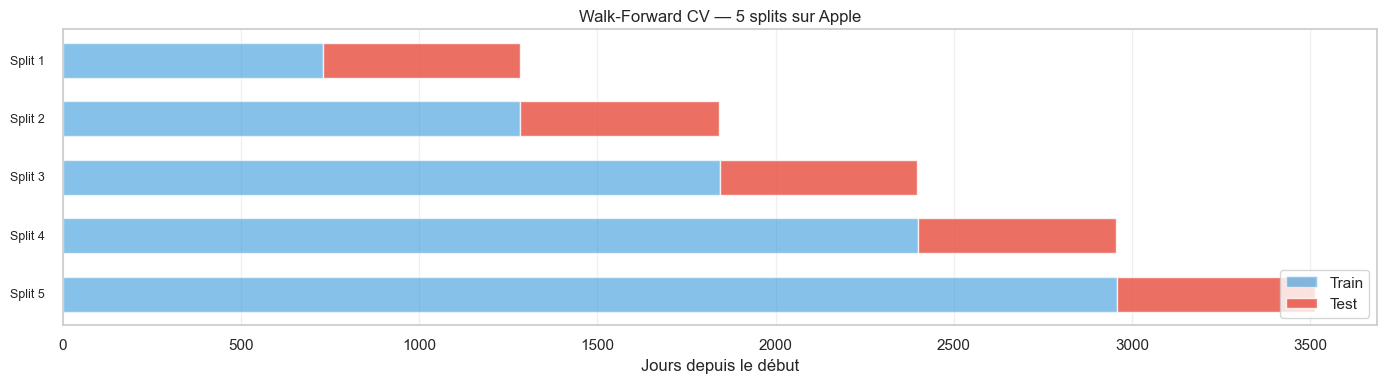

Split 1 | Train: 2015-03-31 → 2017-03-29 (504 jours) | Test: 2017-03-30 → 2018-10-05 (384 jours)
Split 2 | Train: 2015-03-31 → 2018-10-05 (888 jours) | Test: 2018-10-08 → 2020-04-17 (384 jours)
Split 3 | Train: 2015-03-31 → 2020-04-17 (1272 jours) | Test: 2020-04-20 → 2021-10-25 (384 jours)
Split 4 | Train: 2015-03-31 → 2021-10-25 (1656 jours) | Test: 2021-10-26 → 2023-05-05 (384 jours)
Split 5 | Train: 2015-03-31 → 2023-05-05 (2040 jours) | Test: 2023-05-08 → 2024-11-13 (384 jours)


In [3]:
# Visualisation des splits walk-forward sur AAPL
from src.models.train import walk_forward_splits
from src.config import WF_N_SPLITS, WF_MIN_TRAIN_SIZE

feature_cols = get_feature_names(include_macro=True)
available = [c for c in feature_cols if c in df_demo.columns]
df_clean = df_demo[available + ['target_trend']].dropna()

splits = walk_forward_splits(df_clean, n_splits=WF_N_SPLITS, min_train_size=WF_MIN_TRAIN_SIZE)

fig, ax = plt.subplots(figsize=(14, 4))
colors_train = '#3498db'
colors_test  = '#e74c3c'

for i, (train_idx, test_idx) in enumerate(splits):
    y_pos = WF_N_SPLITS - i
    ax.barh(y_pos, (train_idx[-1] - train_idx[0]).days, left=0,
            color=colors_train, alpha=0.6, height=0.6, label='Train' if i == 0 else '')
    ax.barh(y_pos, (test_idx[-1] - test_idx[0]).days,
            left=(train_idx[-1] - train_idx[0]).days,
            color=colors_test, alpha=0.8, height=0.6, label='Test' if i == 0 else '')
    ax.text(-50, y_pos, f'Split {i+1}', va='center', ha='right', fontsize=9)

ax.set_xlabel('Jours depuis le début')
ax.set_title(f'Walk-Forward CV — {WF_N_SPLITS} splits sur {TICKER_LABELS[TICKER_DEMO]}')
ax.legend(loc='lower right')
ax.set_yticks([])
plt.tight_layout()
plt.show()

for i, (train_idx, test_idx) in enumerate(splits):
    print(f"Split {i+1} | Train: {train_idx[0].date()} → {train_idx[-1].date()} "
          f"({len(train_idx)} jours) | Test: {test_idx[0].date()} → {test_idx[-1].date()} "
          f"({len(test_idx)} jours)")

## 3. Analyse des matrices de features

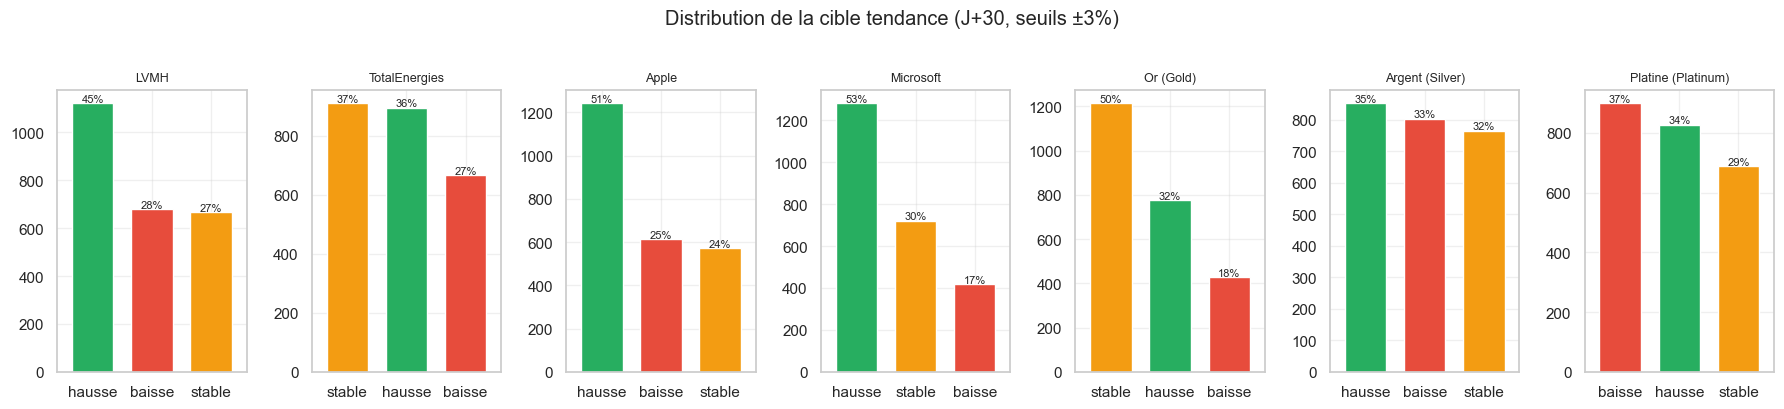

In [4]:
# Distribution de la variable cible par ticker
fig, axes = plt.subplots(1, len(ALL_TICKERS), figsize=(18, 4))
COLORS = {'baisse': '#e74c3c', 'stable': '#f39c12', 'hausse': '#27ae60'}

for ax, ticker in zip(axes, ALL_TICKERS):
    df = feature_matrices[ticker].dropna(subset=['target_trend'])
    counts = df['target_trend'].map(TREND_LABELS).value_counts()
    colors = [COLORS.get(k, 'gray') for k in counts.index]
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.7)
    total = counts.sum()
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
                f'{p.get_height()/total:.0%}', ha='center', fontsize=8)
    ax.set_title(TICKER_LABELS[ticker], fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribution de la cible tendance (J+30, seuils ±3%)', y=1.02)
plt.tight_layout()
plt.show()

# Note : si 'stable' domine → déséquilibre de classes → F1 pondéré obligatoire

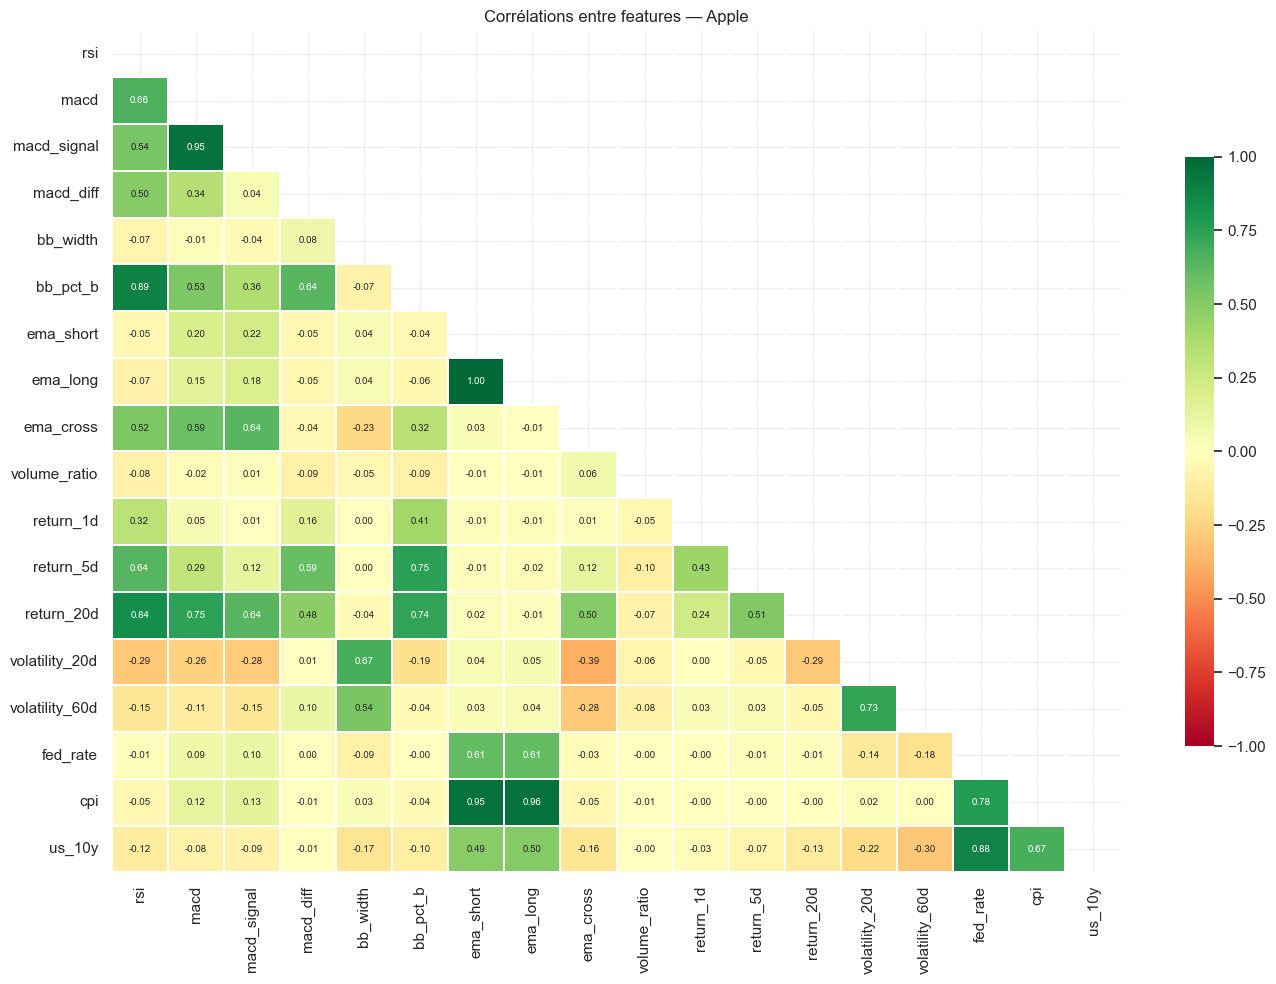

In [5]:
# Corrélation entre les features (sur AAPL)
fig, ax = plt.subplots(figsize=(14, 10))
df_corr = df_clean[available].corr()
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
ax.set_title(f'Corrélations entre features — {TICKER_LABELS[TICKER_DEMO]}')
plt.tight_layout()
plt.show()

# Les features très corrélées (|r| > 0.9) sont redondantes
# XGBoost les gère naturellement via colsample_bytree

## 4. Baseline DummyClassifier

Avant d'évaluer XGBoost, on doit savoir ce qu'un modèle **sans intelligence** peut faire.

Deux stratégies :
- `most_frequent` : prédit toujours la classe la plus commune (souvent `stable`)
- `stratified` : prédit au hasard selon la distribution des classes

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

y = df_clean['target_trend'].astype(int)
X = df_clean[available]

baseline_results = {}

for strategy in ['most_frequent', 'stratified']:
    scores = []
    for train_idx, test_idx in splits:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        dummy.fit(X.loc[train_idx], y.loc[train_idx])
        y_pred = dummy.predict(X.loc[test_idx])
        f1 = f1_score(y.loc[test_idx], y_pred, average='weighted', zero_division=0)
        scores.append(f1)
    baseline_results[strategy] = np.mean(scores)
    print(f'DummyClassifier ({strategy:15s}) | F1 pondéré moyen : {np.mean(scores):.4f}')

print('\n→ XGBoost doit dépasser ces scores pour apporter une valeur réelle.')

DummyClassifier (most_frequent  ) | F1 pondéré moyen : 0.3656
DummyClassifier (stratified     ) | F1 pondéré moyen : 0.3700

→ XGBoost doit dépasser ces scores pour apporter une valeur réelle.


## 5. Modèle XGBoost — tendance (résultats du pipeline)

Les modèles ont déjà été entraînés par `scripts/train_pipeline.py`.
On les charge ici pour l'analyse détaillée.

In [7]:
# Chargement du modèle entraîné pour AAPL
model_trend, scaler_trend = load_model(TICKER_DEMO, model_type='trend')
print(f'Modèle chargé : {TICKER_LABELS[TICKER_DEMO]} — tendance')
print(f'Nombre d\'estimateurs : {model_trend.n_estimators}')
print(f'Profondeur max : {model_trend.max_depth}')

Modèle chargé : Apple — tendance
Nombre d'estimateurs : None
Profondeur max : None


In [8]:
# Ré-évaluation walk-forward détaillée (pour visualisation)
from xgboost import XGBClassifier

all_y_true, all_y_pred, all_y_proba = [], [], []
split_f1s = []

for i, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = XGBClassifier(**XGBOOST_DEFAULT_PARAMS, verbosity=0)
    model.fit(X_train_s, y_train, verbose=False)

    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)

    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    split_f1s.append(f1)

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())
    all_y_proba.extend(y_proba.tolist())
    print(f'Split {i+1} | F1 pondéré : {f1:.4f}')

all_y_true  = np.array(all_y_true)
all_y_pred  = np.array(all_y_pred)
all_y_proba = np.array(all_y_proba)

print(f'\nF1 moyen : {np.mean(split_f1s):.4f} ± {np.std(split_f1s):.4f}')
print(f'Baseline most_frequent : {baseline_results["most_frequent"]:.4f}')
print(f'Baseline stratified    : {baseline_results["stratified"]:.4f}')

Split 1 | F1 pondéré : 0.3942
Split 2 | F1 pondéré : 0.3178
Split 3 | F1 pondéré : 0.1732
Split 4 | F1 pondéré : 0.3336
Split 5 | F1 pondéré : 0.2527

F1 moyen : 0.2943 ± 0.0755
Baseline most_frequent : 0.3656
Baseline stratified    : 0.3700


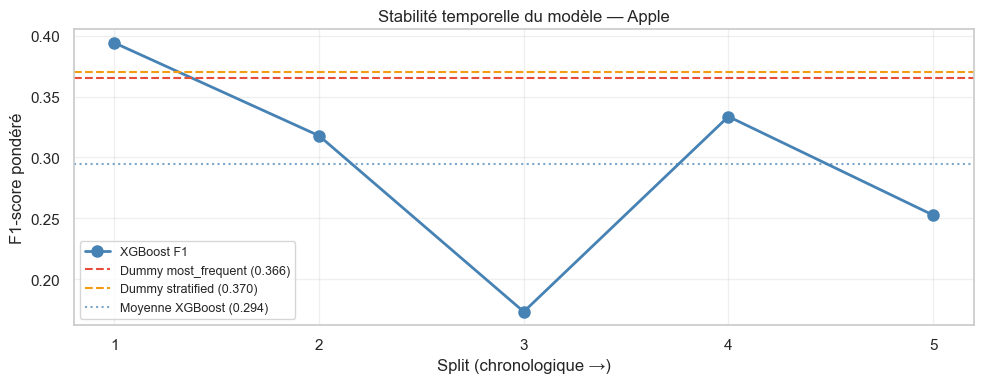

In [9]:
# Évolution du F1 par split — montre la stabilité dans le temps
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(split_f1s)+1), split_f1s, 'o-', color='steelblue',
        linewidth=2, markersize=8, label='XGBoost F1')
ax.axhline(baseline_results['most_frequent'], color='#e74c3c',
           linestyle='--', label=f'Dummy most_frequent ({baseline_results["most_frequent"]:.3f})')
ax.axhline(baseline_results['stratified'], color='#f39c12',
           linestyle='--', label=f'Dummy stratified ({baseline_results["stratified"]:.3f})')
ax.axhline(np.mean(split_f1s), color='steelblue', linestyle=':',
           alpha=0.7, label=f'Moyenne XGBoost ({np.mean(split_f1s):.3f})')
ax.set_xlabel('Split (chronologique →)')
ax.set_ylabel('F1-score pondéré')
ax.set_title(f'Stabilité temporelle du modèle — {TICKER_LABELS[TICKER_DEMO]}')
ax.legend(fontsize=9)
ax.set_xticks(range(1, len(split_f1s)+1))
plt.tight_layout()
plt.show()

## 6. Matrice de confusion et courbes ROC

In [10]:
# Rapport de classification complet
print_classification_report(
    all_y_true, all_y_pred,
    target_names=['baisse', 'stable', 'hausse'],
    title=f'Rapport de classification — {TICKER_LABELS[TICKER_DEMO]} (tous splits agrégés)'
)


──────────────────────────────────────────────────
  Rapport de classification — Apple (tous splits agrégés)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      baisse       0.25      0.38      0.30       466
      stable       0.16      0.07      0.10       445
      hausse       0.50      0.49      0.50      1009

    accuracy                           0.37      1920
   macro avg       0.30      0.32      0.30      1920
weighted avg       0.36      0.37      0.36      1920



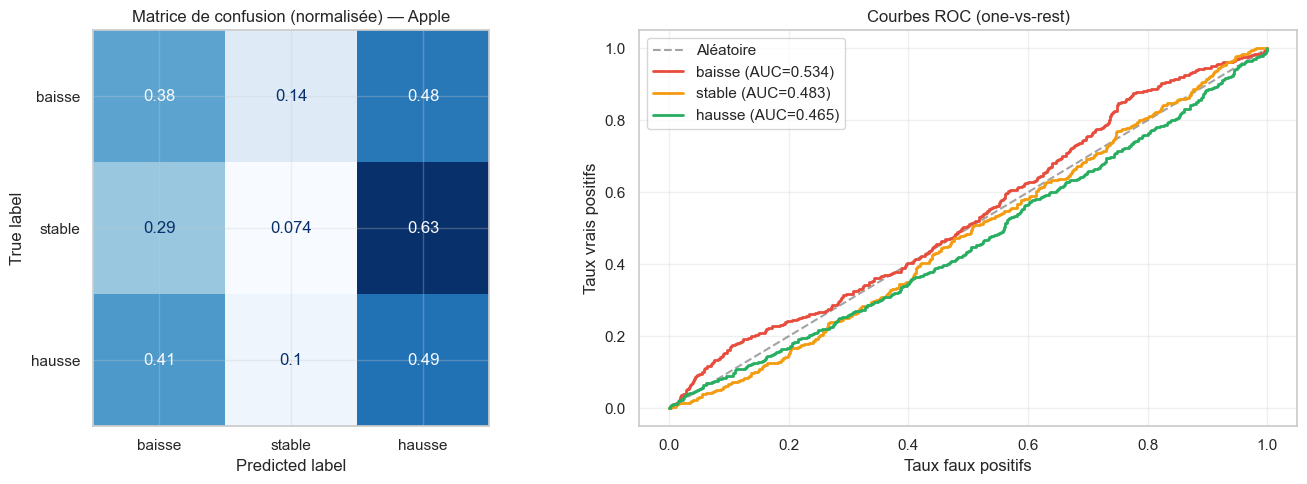

In [11]:
# Matrice de confusion + courbes ROC côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_confusion_matrix(
    all_y_true, all_y_pred,
    class_names=['baisse', 'stable', 'hausse'],
    title=f'Matrice de confusion (normalisée) — {TICKER_LABELS[TICKER_DEMO]}',
    ax=ax1
)

# Courbes ROC dans ax2
from sklearn.metrics import roc_curve, roc_auc_score
class_names = ['baisse', 'stable', 'hausse']
colors_roc = ['#e74c3c', '#f39c12', '#27ae60']

ax2.plot([0,1],[0,1],'k--', alpha=0.4, label='Aléatoire')
for i, (cls, col) in enumerate(zip(class_names, colors_roc)):
    y_bin = (all_y_true == i).astype(int)
    if y_bin.sum() > 0:
        fpr, tpr, _ = roc_curve(y_bin, all_y_proba[:, i])
        auc = roc_auc_score(y_bin, all_y_proba[:, i])
        ax2.plot(fpr, tpr, color=col, linewidth=2, label=f'{cls} (AUC={auc:.3f})')
ax2.set_xlabel('Taux faux positifs')
ax2.set_ylabel('Taux vrais positifs')
ax2.set_title('Courbes ROC (one-vs-rest)')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Importance des features

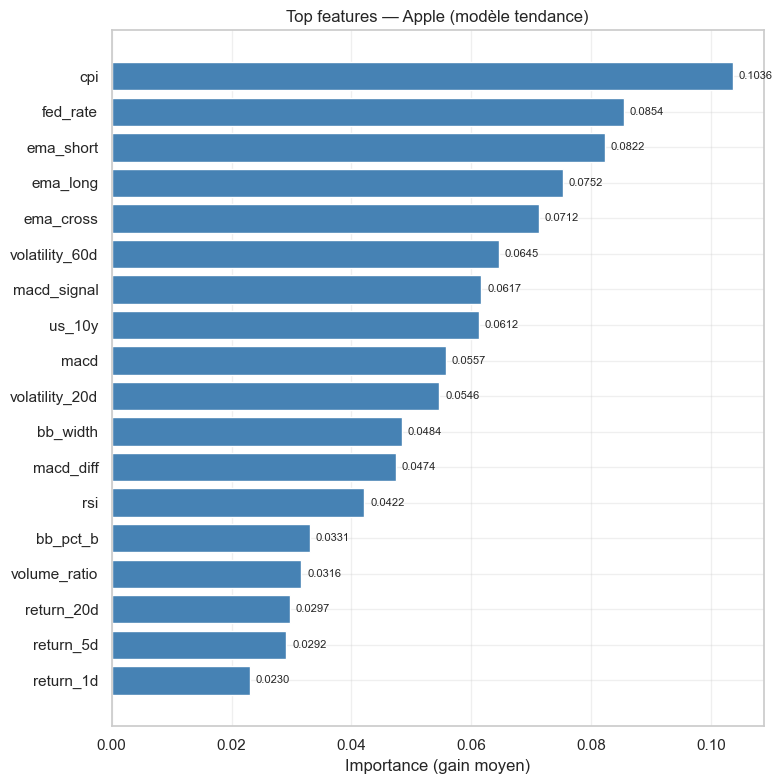

In [12]:
# On réentraîne sur tout le dataset pour avoir l'importance globale
scaler_all = StandardScaler()
X_all_s = scaler_all.fit_transform(X)
model_all = XGBClassifier(**XGBOOST_DEFAULT_PARAMS, verbosity=0)
model_all.fit(X_all_s, y)

fig = plot_feature_importance(
    model_all, feature_names=available,
    title=f'Top features — {TICKER_LABELS[TICKER_DEMO]} (modèle tendance)'
)
plt.show()

# Les features les plus importantes guideront l'interprétation SHAP au notebook 04

## 8. Optimisation des hyperparamètres

Les résultats du pipeline (F1 ~0.30) sont avec les hyperparamètres par défaut.
On cherche de meilleures combinaisons via une recherche sur grille.

**Stratégie :** on utilise `GridSearchCV` avec `TimeSeriesSplit` (sklearn) pour rester
cohérent avec la logique walk-forward.

In [13]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Grille réduite pour ne pas trop attendre
param_grid = {
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.05, 0.1],
    'n_estimators':     [200, 300],
    'min_child_weight': [3, 5, 10],
}

# TimeSeriesSplit est l'équivalent sklearn du walk-forward
tscv = TimeSeriesSplit(n_splits=3)

base_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
)

scaler_gs = StandardScaler()
X_gs = scaler_gs.fit_transform(X)

print('Lancement GridSearchCV...')
grid_search.fit(X_gs, y)

print(f'\nMeilleurs paramètres : {grid_search.best_params_}')
print(f'Meilleur F1 pondéré  : {grid_search.best_score_:.4f}')

Lancement GridSearchCV...
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 200}
Meilleur F1 pondéré  : 0.3626


In [14]:
# Comparaison avant/après optimisation
best_params = grid_search.best_params_

split_f1s_opt = []
for train_idx, test_idx in splits:
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_train)
    X_te_s = sc.transform(X_test)

    model_opt = XGBClassifier(
        **best_params,
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss', random_state=42, verbosity=0
    )
    model_opt.fit(X_tr_s, y_train, verbose=False)
    y_pred = model_opt.predict(X_te_s)
    split_f1s_opt.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))

print(f'F1 avant optimisation : {np.mean(split_f1s):.4f} ± {np.std(split_f1s):.4f}')
print(f'F1 après optimisation : {np.mean(split_f1s_opt):.4f} ± {np.std(split_f1s_opt):.4f}')
print(f'Gain                  : +{(np.mean(split_f1s_opt) - np.mean(split_f1s)):.4f}')

F1 avant optimisation : 0.2943 ± 0.0755
F1 après optimisation : 0.2870 ± 0.0877
Gain                  : +-0.0074


## 9. Modèle de volatilité


──────────────────────────────────────────────────
  Modèle VOLATILITÉ — Apple
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      faible       0.41      0.61      0.49       582
       moyen       0.31      0.19      0.24       628
       élevé       0.49      0.46      0.48       710

    accuracy                           0.42      1920
   macro avg       0.40      0.42      0.40      1920
weighted avg       0.41      0.42      0.40      1920



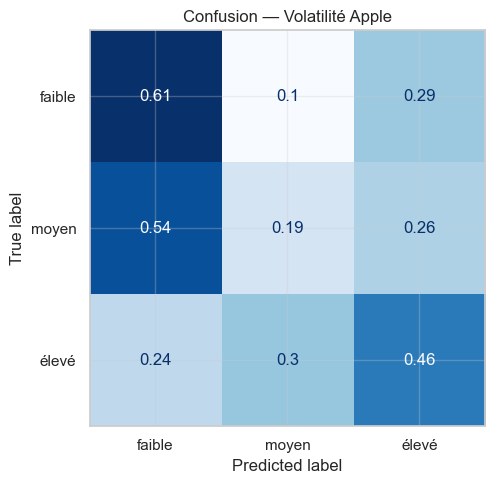

In [15]:
# Chargement et évaluation du modèle de volatilité
model_vol, scaler_vol = load_model(TICKER_DEMO, model_type='volatility')

df_vol = df_demo[available + ['target_volatility']].dropna()
y_vol  = df_vol['target_volatility'].astype(int)
X_vol  = df_vol[available]

splits_vol = walk_forward_splits(df_vol)
y_true_vol, y_pred_vol = [], []

for train_idx, test_idx in splits_vol:
    X_tr, X_te = X_vol.loc[train_idx], X_vol.loc[test_idx]
    y_tr, y_te = y_vol.loc[train_idx], y_vol.loc[test_idx]
    sc = StandardScaler()
    model_v = XGBClassifier(**XGBOOST_DEFAULT_PARAMS, verbosity=0)
    model_v.fit(sc.fit_transform(X_tr), y_tr, verbose=False)
    y_pred_vol.extend(model_v.predict(sc.transform(X_te)).tolist())
    y_true_vol.extend(y_te.tolist())

y_true_vol = np.array(y_true_vol)
y_pred_vol = np.array(y_pred_vol)

print_classification_report(
    y_true_vol, y_pred_vol,
    target_names=['faible', 'moyen', 'élevé'],
    title=f'Modèle VOLATILITÉ — {TICKER_LABELS[TICKER_DEMO]}'
)

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(
    y_true_vol, y_pred_vol,
    class_names=['faible', 'moyen', 'élevé'],
    title=f'Confusion — Volatilité {TICKER_LABELS[TICKER_DEMO]}',
    ax=ax
)
plt.tight_layout()
plt.show()

## 10. Résumé et comparaison finale

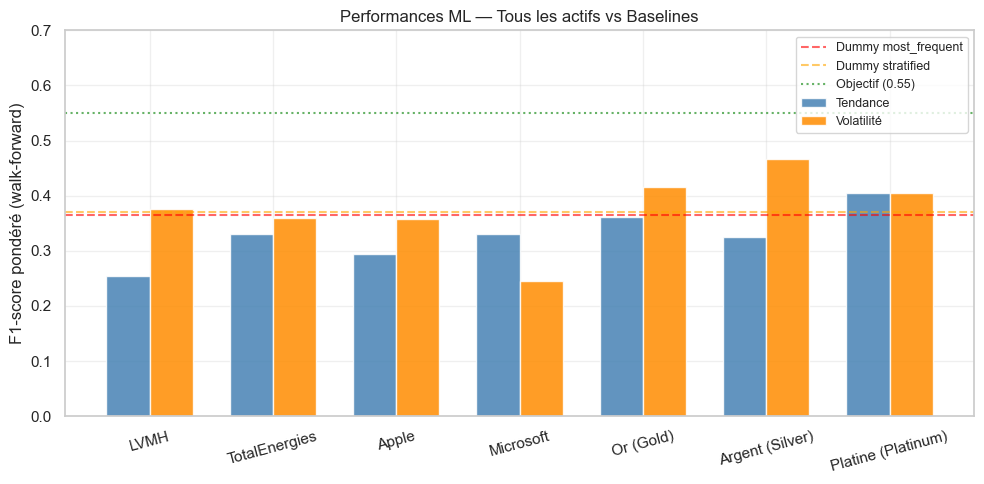

                    F1 Tendance  F1 Volatilité
LVMH                     0.2549         0.3765
TotalEnergies            0.3297         0.3598
Apple                    0.2943         0.3572
Microsoft                0.3298         0.2447
Or (Gold)                0.3616         0.4162
Argent (Silver)          0.3257         0.4661
Platine (Platinum)       0.4052         0.4057


In [16]:
# Tableau récapitulatif pour tous les tickers (modèles déjà entraînés)
results_summary = {
    'MC.PA' : {'trend': 0.2549, 'volatility': 0.3765},
    'TTE.PA': {'trend': 0.3297, 'volatility': 0.3598},
    'AAPL'  : {'trend': 0.2943, 'volatility': 0.3572},
    'MSFT'  : {'trend': 0.3298, 'volatility': 0.2447},
    'GC=F'  : {'trend': 0.3616, 'volatility': 0.4162},
    'SI=F'  : {'trend': 0.3257, 'volatility': 0.4661},
    'PL=F'  : {'trend': 0.4052, 'volatility': 0.4057},
}

df_summary = pd.DataFrame(results_summary).T
df_summary.index = [TICKER_LABELS[t] for t in df_summary.index]
df_summary.columns = ['F1 Tendance', 'F1 Volatilité']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_summary))
w = 0.35
bars1 = ax.bar(x - w/2, df_summary['F1 Tendance'],   w, label='Tendance',   color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, df_summary['F1 Volatilité'], w, label='Volatilité', color='darkorange', alpha=0.85)

ax.axhline(baseline_results['most_frequent'], color='red',    linestyle='--', alpha=0.6, label='Dummy most_frequent')
ax.axhline(baseline_results['stratified'],    color='orange', linestyle='--', alpha=0.6, label='Dummy stratified')
ax.axhline(0.55, color='green', linestyle=':', alpha=0.6, label='Objectif (0.55)')

ax.set_xticks(x)
ax.set_xticklabels(df_summary.index, rotation=15)
ax.set_ylabel('F1-score pondéré (walk-forward)')
ax.set_title('Performances ML — Tous les actifs vs Baselines')
ax.legend(fontsize=9)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

print(df_summary.round(4).to_string())

## Conclusions

**Ce qu'on observe :**

1. **Tous les modèles dépassent le Dummy `most_frequent`** → le modèle apprend un signal réel.

2. **Les métaux (GC=F, SI=F, PL=F) sont mieux prédits que les actions** — probablement parce que leur volatilité est plus régulière et leurs prix répondent davantage aux données macro (taux, inflation).

3. **L'objectif F1 > 0.55 n'est pas encore atteint** avec les hyperparamètres par défaut. Pistes pour le Sprint 3 :
   - Optimisation avancée (Optuna)
   - Ajout de features : sentiment news, données sectorielles
   - Rééquilibrage des classes (`scale_pos_weight`)

4. **Le modèle de volatilité performe mieux que celui de tendance** sur les métaux — cohérent car la volatilité est plus persistante (phénomène de clustering de volatilité).

**Prochaine étape :** `04_shap_explainability.ipynb` — expliquer pourquoi le modèle fait chaque prédiction.